# Using Machine Learning to predict Ontario Housing Prices

| Alec De Sousa | Hermes Hui | 
| :---: | :---: |
| 500918882 |  500763595 |
| alec.desousa@torontomu.ca | hchui@torontomu.ca |

In [78]:
# Import libraries and read cleaned data

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import shap

data = pd.read_csv("data_on - Shortened.csv")
big_data = pd.read_csv("data_on - Shortened.csv")

### K-Means Clustering

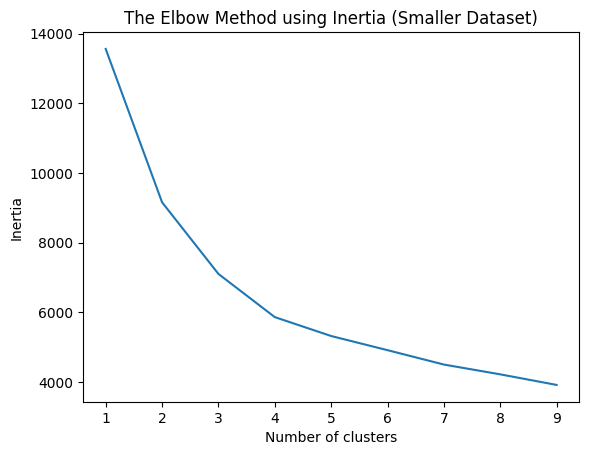

Silhouette score for k = 3: 0.33976543966177125


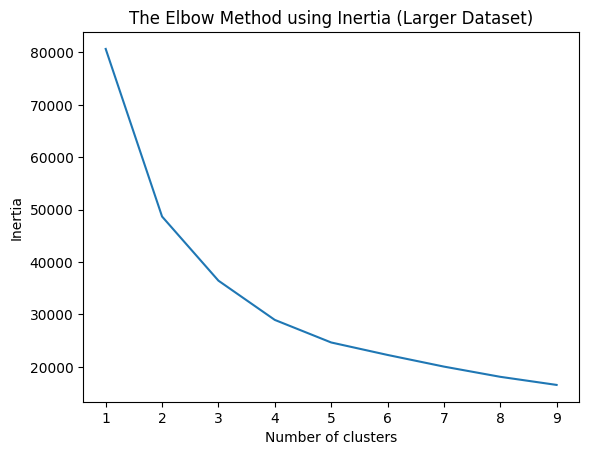

Silhouette score for k = 3: 0.459254970200519

+-----------------------------------------------------------------+
| Descriptive Statistics of the Smaller Dataset (2,261 Instances) |
+-----------------------------------------------------------------+

+-----------------+
| Cluster by mean |
+-----------------+
                price  property-beds  property-baths  property-sqft      Bath  \
cluster                                                                         
0        7.546830e+05       3.148492        2.755607    1690.491106  1.038670   
1        2.065632e+06       4.835351        4.375303    3762.530266  1.145278   
2        3.763449e+05       3.097473        1.671480    1295.758123  0.016245   

         price-per-sqft  
cluster                  
0            455.745838  
1            564.353290  
2            291.700662  

+-------------------+
| Cluster by median |
+-------------------+
             price  property-beds  property-baths  property-sqft  Bath  \
cluster    

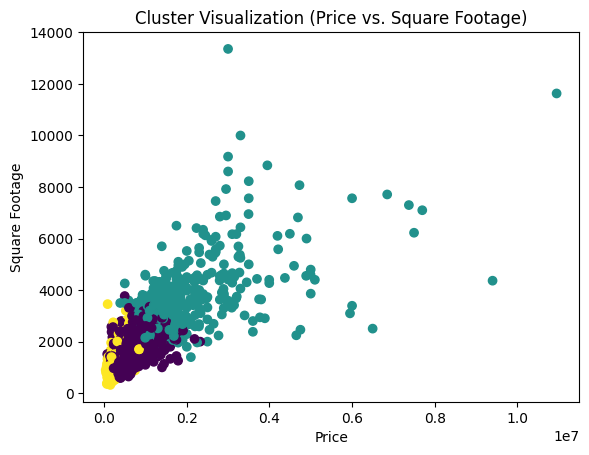

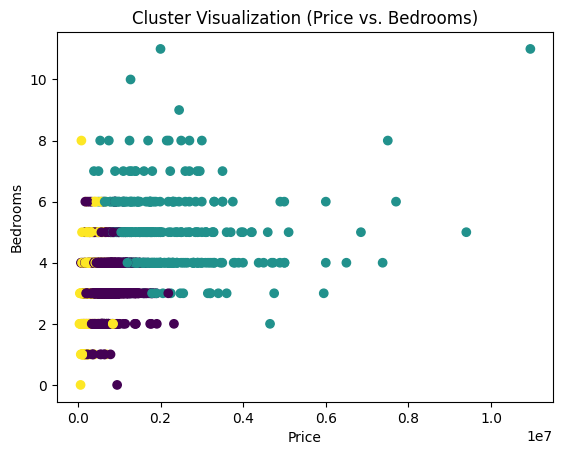


+-----------------------------------------------------------------+
| Descriptive Statistics of the Larger Dataset (26,890 Instances) |
+-----------------------------------------------------------------+

+-----------------+
| Cluster by mean |
+-----------------+
                price  property-beds  property-baths
cluster                                             
0        6.854113e+05       2.368237        1.792803
1        6.966483e+06       6.347048        6.872987
2        1.485683e+06       4.721919        3.770823

+-------------------+
| Cluster by median |
+-------------------+
             price  property-beds  property-baths
cluster                                          
0         634900.0            2.0             2.0
1        5500000.0            6.0             7.0
2        1278000.0            4.0             4.0

+-------------------------------+
| Cluster by variation (scaled) |
+-------------------------------+
price             2.664251
property-baths    1.74

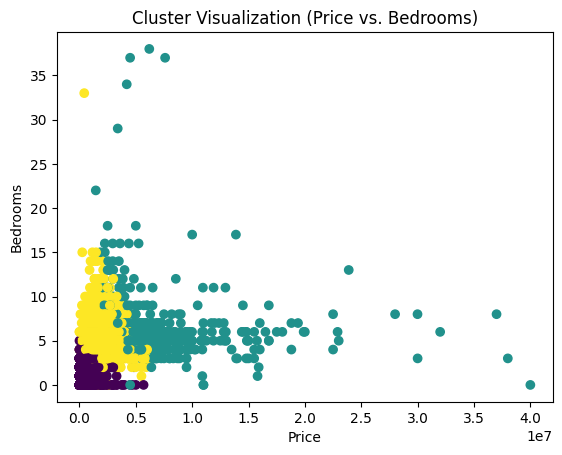

In [82]:
# Clustering only works with numerical data, so only read numeric attributes
# That said, having the square footage of the house would be nice, but it's in string format, so must convert it
data["property-sqft"] = (
    data["property-sqft"]
    .astype(str)                # Ensure data is a string
    .str.replace("sqft", "")    # Remove the "sqft" text
    .str.replace(",", "")       # Remove commas
    .str.replace(" ", "")       # Remove any spaces
)

# Conversion from string to numeric
data["property-sqft"] = pd.to_numeric(data["property-sqft"])

# Now that we have sqft in numeric, we can take the oppurtunity to create a price per sqft attribute
data["price-per-sqft"] = data["price"] / data["property-sqft"]

# Now that everything we want is in numerical format, we can continue
data_numeric = data.select_dtypes(include=["int64","float64"])
data_numeric = data_numeric.dropna() # Handling missing values
data_numeric = data_numeric.drop(columns = ["Partial Bathroom"])

# After some analysis, the most expensive house in the dataset is more than double the price of the 2nd most expensive.
# Removing that outlier here:
outlier = data_numeric["price"].idxmax()
data_numeric = data_numeric.drop(index = outlier)

# In the dataset, property-sqft has 24,670 instances without data. Additionally, Bath and Partial Bathroom have 16,812 instances without data.
# This means that data_numeric only has 2,261 total instances (out of 29,579 original instances). It's hard to deny that's a lot of data lost.
# Because of this, another dataframe "big_data_numeric" will be created, ignoring property-sqft, Bath, and Partial Bathroom. Because of this,
# big_data_numeric can drop any instances with missing data, and still total 26,890 instances.
big_data_numeric = big_data[["price", "property-beds", "property-baths",]]
big_data_numeric = big_data_numeric.dropna()
big_outlier = big_data_numeric["property-beds"].idxmax() # There's one property with 70 bedrooms, which muddies the scatterplot latter
big_data_numeric = big_data_numeric.drop(index = big_outlier)

# Using StandardScaler from the scikit-learn library to scale the data (very important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_numeric)
big_X_scaled = scaler.fit_transform(big_data_numeric)

# Now that the data is scaled, we can apply K-means clustering. We must first figure out what our K should be.
# Using the elbow method [https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/], we can
# Create a graph using the matplotlib library in order to find the "elbow" of the graph. This tells us what the optimal K should be.
inertia = []
big_inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=11, n_init = 10) # As long as random_state is the same, the results will be reproducible
                                                                # Also, n_init is how many times K-means runs, choosing the best (in this case, 10 runs)
    big_kmeans = KMeans(n_clusters=k, random_state=11, n_init = 10)
    kmeans.fit(X_scaled)
    big_kmeans.fit(big_X_scaled)
    inertia.append(kmeans.inertia_)
    big_inertia.append(big_kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.title("The Elbow Method using Inertia (Smaller Dataset)")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

# The graph shows that the optimal k is likely either 2 or 3. After calculating the silhouette score, the results were:
# k = 2: 0.3494088712259932
# k = 3: 0.33976543966177125
# k = 4: 0.3212048695206462
# k = 2 is the highest value, and therefore more optimal. That said, k = 3 will provide more options for a prospective house buyer.
# Because of this, while technically suboptimal, we will use k = 3.

# Now that we have the our k value (k = 3), we can apply K-means clustering using scikit-learn library
kmeans = KMeans(n_clusters = 3, random_state = 11, n_init = 10)
kmeans.fit(X_scaled)

# The same for big data
# k = 2: 0.48395953927574265
# k = 3: 0.45847778673449335
# k = 4: 0.41355569283082505
big_kmeans = KMeans(n_clusters = 3, random_state = 11, n_init = 10)
big_kmeans.fit(big_X_scaled)

data_numeric["cluster"] = kmeans.labels_
big_data_numeric["cluster"] = big_kmeans.labels_

# From the graph, k = 3 seems to be optimal. But to be sure, we'll check using the scikit-learn library's silhouette score function
score = silhouette_score(X_scaled, data_numeric["cluster"])
print("Silhouette score for k = 3:", score)
#print("From the above graph and silhouette score, k = 3 is the most optimal value for k.")

plt.plot(range(1, 10), big_inertia)
plt.title("The Elbow Method using Inertia (Larger Dataset)")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()
big_score = silhouette_score(big_X_scaled, big_data_numeric["cluster"])
print("Silhouette score for k = 3:", big_score)

print("\n+-----------------------------------------------------------------+")
print("| Descriptive Statistics of the Smaller Dataset (2,261 Instances) |")
print("+-----------------------------------------------------------------+")

print("\n+-----------------+")
print("| Cluster by mean |")
print("+-----------------+")
print(data_numeric.groupby("cluster").mean())

print("\n+-------------------+")
print("| Cluster by median |")
print("+-------------------+")
print(data_numeric.groupby("cluster").median())

# To show what attributes have the most effect on clustering
print("\n+-------------------------------+")
print("| Cluster by variation (scaled) |")
print("+-------------------------------+")

# Converting X_scaled into a dataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns = data_numeric.columns.drop("cluster"))
X_scaled_df["cluster"] = kmeans.labels_

print(X_scaled_df.groupby("cluster").mean().std().sort_values(ascending = False))
print("\n")

# Create a graph to visualize the clusters we just found
plt.scatter(data_numeric["price"], data_numeric["property-sqft"], c = data_numeric["cluster"])
plt.title("Cluster Visualization (Price vs. Square Footage)")
plt.xlabel("Price")
plt.ylabel("Square Footage")
plt.show()

# This graph can be compared to the bigger dataset (because the bigger dataset is missing sqft)
plt.scatter(data_numeric["price"], data_numeric["property-beds"], c = data_numeric["cluster"])
plt.title("Cluster Visualization (Price vs. Bedrooms)")
plt.xlabel("Price")
plt.ylabel("Bedrooms")
plt.show()

# Doing the same as above for the bigger dataset
print("\n+-----------------------------------------------------------------+")
print("| Descriptive Statistics of the Larger Dataset (26,890 Instances) |")
print("+-----------------------------------------------------------------+")

print("\n+-----------------+")
print("| Cluster by mean |")
print("+-----------------+")
print(big_data_numeric.groupby("cluster").mean())

print("\n+-------------------+")
print("| Cluster by median |")
print("+-------------------+")
print(big_data_numeric.groupby("cluster").median())

# To show what attributes have the most effect on clustering
print("\n+-------------------------------+")
print("| Cluster by variation (scaled) |")
print("+-------------------------------+")

# Converting X_scaled into a dataFrame
big_X_scaled_df = pd.DataFrame(big_X_scaled, columns = big_data_numeric.columns.drop("cluster"))
big_X_scaled_df["cluster"] = big_kmeans.labels_

print(big_X_scaled_df.groupby("cluster").mean().std().sort_values(ascending = False))
print("\n")

# Create a graph to visualize the clusters we just found
plt.scatter(big_data_numeric["price"], big_data_numeric["property-beds"], c = big_data_numeric["cluster"])
plt.title("Cluster Visualization (Price vs. Bedrooms)")
plt.xlabel("Price")
plt.ylabel("Bedrooms")
plt.show()

#### Association Rules

In [80]:
# Creating categories for the numeric attributes. Partial bathroom isn't included, as it has the same values as Baths 
# and will skew the association rules

# Price: 0 to 618,999 = low, 619,000 to 999,998 = med, 999,999 to 123,123,123 
# Beds: 0-2 = low, 3-4 = mid, 5-10 = high
# Bathrooms: 0-1 = low, 2-3 = mid, 3-10 = high
# Square footage: 1 to 1183 = low, 1184 to 1893 = med, 1894 to 419000 = high
# Bathtubs: 0-1 = low, 2 = mid, 3-10 = high
# Price per Sqft: 0.0000323 366.12 to = low, 366.13 to 531.55 = med, 531.56 to 4995000 = high
data["price-categories"] = pd.qcut(data["price"], q = 3, labels = ["low", "med", "high"])
data["beds-categories"] = pd.cut(data["property-beds"], bins = [-1, 2, 4, 10], labels = ["low", "med", "high"])
data["bathrooms-categories"] = pd.cut(data["property-baths"], bins = [-1, 1, 3, 10], labels = ["low", "med", "high"])
data["sqft-categories"] = pd.qcut(data["property-sqft"], q = 3, labels = ["low", "med", "high"])
data["bathtubs-categories"] = pd.cut(data["Bath"], bins = [-1, 1, 2, 10], labels = ["low", "med", "high"])
data["price-per-sqft-categories"] = pd.qcut(data["price-per-sqft"], q = 3, labels = ["low", "med", "high"])

# Including the clusters made earlier, and converting it into a string
data["cluster"] = data_numeric["cluster"]
data["cluster"] = data["cluster"].astype(str)
data["cluster-big-dataset"] = big_data_numeric["cluster"]
data["cluster-big-dataset"] = data["cluster-big-dataset"].astype(str)

# Additionally, adding addressLocality. That said, addressLocality isn't suitable for association rules by itself (too many options with sparse data,
# which translates to very weak rules). To circumvent this issue, we find the top 10 most common localities, and group everything else into "other".
# This will avoid sparse data, while keeping meaningful locations to make associations with.

# Before that, however, we will clean the data to merge things like "Thunder Bay" and "THUNDER BAY", or "Ajax (Central East)" and "Ajax (Central West)"
data["addressLocality"] = (
    data["addressLocality"]
        .str.lower()                               # Turns everything lowercase
        .str.replace(r"\(.*?\)", "", regex = True) # Remove brackets and what's inside them
        .str.strip()                               # Removes white space at the beginning and end of the data
        .str.title()                               # Capitalizes the first letter to enhance readability
)

# Now, we can group the localities
top_localities = data["addressLocality"].value_counts().nlargest(10).index # Finding the top 10 localities
data["locality-group"] = data["addressLocality"].apply(lambda x: x if x in top_localities else "Other") # If data isn't in top localities, group into "Other"

# OK, now we can find the association rules. Additionally, various other categorical attributes from the original dataset were added
data_rules = data[[
    "price-categories",
    "beds-categories",
    "bathrooms-categories",
    "sqft-categories",
    "bathtubs-categories",
    "price-per-sqft-categories",
    "cluster",
    "locality-group",
    "Basement",
    "Exterior",
    "Fireplace",
    "Garage",
    "Heating",
    "Property Type",
    "Roof",
    "Sewer",
    "Parking",
    "Flooring"
    ]]

# Encoding the categorical attributes
data_encoded = pd.get_dummies(data_rules)

# Using mlxtend library to run apriori, then generating the association rules
frequent_itemsets = apriori(data_encoded, min_support = 0.19, use_colnames = True) # min = 0.07
rules = association_rules(frequent_itemsets, metric = "confidence", min_threshold = 0.8) # min = 0.8

# Turns support (percentage of the dataset) into support_count (total numbers)
rules["support_count"] = rules["support"] * len(data_encoded)

# Sort by confidence in descending order, and show top 10 rules
top_rules = rules.sort_values(by = "confidence", ascending = False).head(10)

# Printing the rules as a string for readability
rule_strings = []
print("10 Association Rules:")

for _, row in top_rules.iterrows():
    antecedent = ", ".join(list(row["antecedents"]))
    consequent = ", ".join(list(row["consequents"]))
    support = int(row["support_count"])
    confidence = row["confidence"]

    rule_str = f"IF {antecedent} THEN {consequent} (support_count = {support}, confidence={confidence:.2f})"
    rule_strings.append(rule_str)

for r in rule_strings:
    print(r)

# Use to check the cut-offs for a cut attibute
#_, price_bins = pd.qcut(data["price-per-sqft"], q = 3, retbins = True)
#print(price_bins)


10 Association Rules:
IF bathtubs-categories_low, Sewer_Sanitary sewer THEN Property Type_Single Family (support_count = 5799, confidence=1.00)
IF Sewer_Sanitary sewer, Heating_Forced air, Natural gas THEN Property Type_Single Family (support_count = 8241, confidence=0.99)
IF Sewer_Sanitary sewer THEN Property Type_Single Family (support_count = 8874, confidence=0.95)
IF Fireplace_Yes, price-categories_high THEN Property Type_Single Family (support_count = 5656, confidence=0.94)
IF bathrooms-categories_high THEN Property Type_Single Family (support_count = 5855, confidence=0.93)
IF Sewer_Sanitary sewer, Property Type_Single Family THEN Heating_Forced air, Natural gas (support_count = 8241, confidence=0.93)
IF bathtubs-categories_low, Fireplace_Yes THEN Property Type_Single Family (support_count = 5633, confidence=0.92)
IF Heating_Forced air, Natural gas, Fireplace_Yes THEN Property Type_Single Family (support_count = 5678, confidence=0.90)
IF Sewer_Sanitary sewer THEN Heating_Forced ai

## Decision Tree

In [81]:
# Remove NaNs if any from dataset
data_dtree = data.dropna(subset = ['cluster'])
feature_cols = ['locality-group', 'beds-categories', 'bathrooms-categories',
                 'sqft-categories', 'bathtubs-categories', 'partial-bathrooms-categories']
X_dtree = pd.get_dummies(data_dtree[feature_cols])
y_dtree = data_dtree['cluster'].astype(float).astype(int)

# Split Training and Test Datasets
X_train, X_test, y_train, y_test = train_test_split(X_dtree, y_dtree, test_size = 0.2, random_state = 42)

# Create and Train Decision Tree
dtree_model = DecisionTreeClassifier(max_depth = 8, random_state = 42)
dtree_model.fit(X_train, y_train)

# Extract and print Decision Tree Rules
dtree_rules = export_text(dtree_model, feature_names = list(X_dtree.columns))
print(dtree_rules)

# Visualize the Decision Tree
plt.figure(figsize = (75, 15))
plot_tree(dtree_model, feature_names = X_dtree.columns, class_names = [str(c) for c in dtree_model.classes_], filled = True, rounded = True, fontsize = 12)
plt.show()

# Conduct SHAP analysis on Decision Tree
shap_explainer = shap.TreeExplainer(dtree_model)
shap_values = shap_explainer.shap_values(X_test)

# Visual SHAP results
shap.summary_plot(shap_values, X_test, plot_type = 'bar', plot_size = (30, 10))

KeyError: "['partial-bathrooms-categories'] not in index"